In [ ]:
# Benchmarking Machine Learning Classifiers for Heart Disease Prediction
**Dataset:** Personal Key Indicators of Heart Disease (Kaggle)  
**Models:** SVM · K-Nearest Neighbors · Gaussian Naive Bayes
---

In [ ]:
# 0. Setup — Install & Import Libraries

In [7]:
# ── Standard library and data handling ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset (consolidated here for robustness)
df = pd.read_csv('heart_2020_cleaned.csv')

# ── Scikit-learn: preprocessing ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Scikit-learn: models ─────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ── Scikit-learn: evaluation ─────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Plot aesthetics ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Load the Dataset

> **Kaggle dataset:** *Personal Key Indicators of Heart Disease*  
> Download `heart_2020_cleaned.csv` from https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease  
> Place the CSV in the same directory as this notebook.

In [8]:
# The dataset is now loaded in the initial setup cell (TPyOlaR3B-Ij).
# This cell now serves to inspect the loaded DataFrame.

print(f'Shape: {df.shape}')
df.head()

Shape: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


---
## 2. Exploratory Data Analysis (EDA)

In [9]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe(include='all')

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  str    
 16  KidneyDise

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
count,319795,319795.000000,319795,319795,319795,319795.00000,319795.000000,319795,319795,319795,319795,319795,319795,319795,319795.000000,319795,319795,319795
unique,2,NaN,2,2,2,NaN,NaN,2,2,13,6,4,2,5,NaN,2,2,2
top,No,NaN,No,No,No,NaN,NaN,No,Female,65-69,White,No,Yes,Very good,NaN,No,No,No
freq,292422,NaN,187887,298018,307726,NaN,NaN,275385,167805,34151,245212,269653,247957,113858,NaN,276923,308016,289976
mean,NaN,28.325399,NaN,NaN,NaN,3.37171,3.898366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.097075,NaN,NaN,NaN
std,NaN,6.356100,NaN,NaN,NaN,7.95085,7.955235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.436007,NaN,NaN,NaN
min,NaN,12.020000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,24.030000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN
50%,NaN,27.340000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN
75%,NaN,31.420000,NaN,NaN,NaN,2.00000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN


In [10]:
# ── Missing value audit ───────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column:
No missing values found.


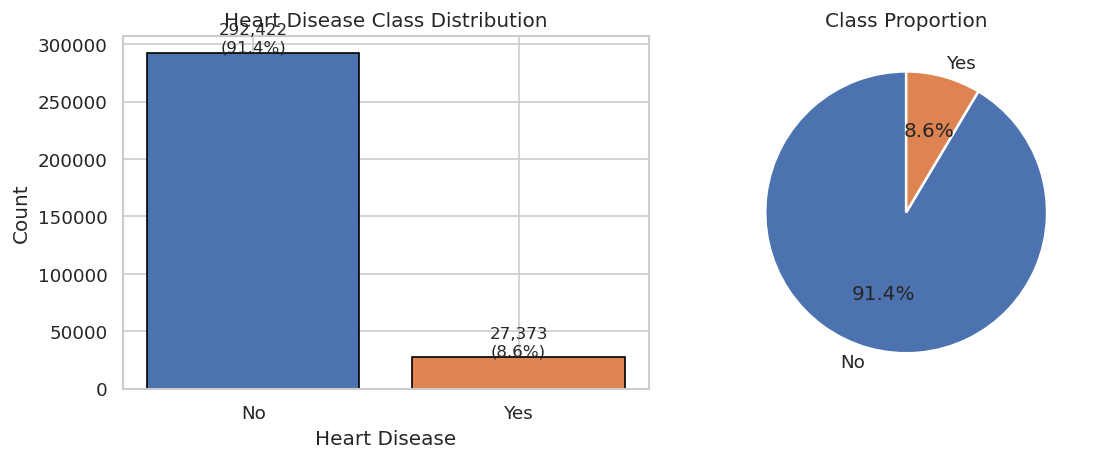

Class imbalance ratio (No:Yes) = 10.7 :1


In [11]:
class_counts = df['HeartDisease'].value_counts()
class_pct    = df['HeartDisease'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Heart Disease Class Distribution')
axes[0].set_xlabel('Heart Disease')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(class_counts.items()):
    axes[0].text(i, count + 1000, f'{count:,}\n({class_pct[label]:.1f}%)',
                 ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('target_imbalance.png', bbox_inches='tight') # Changed filename
plt.show()
print('Class imbalance ratio (No:Yes) =', round(class_counts['No']/class_counts['Yes'], 1), ':1')

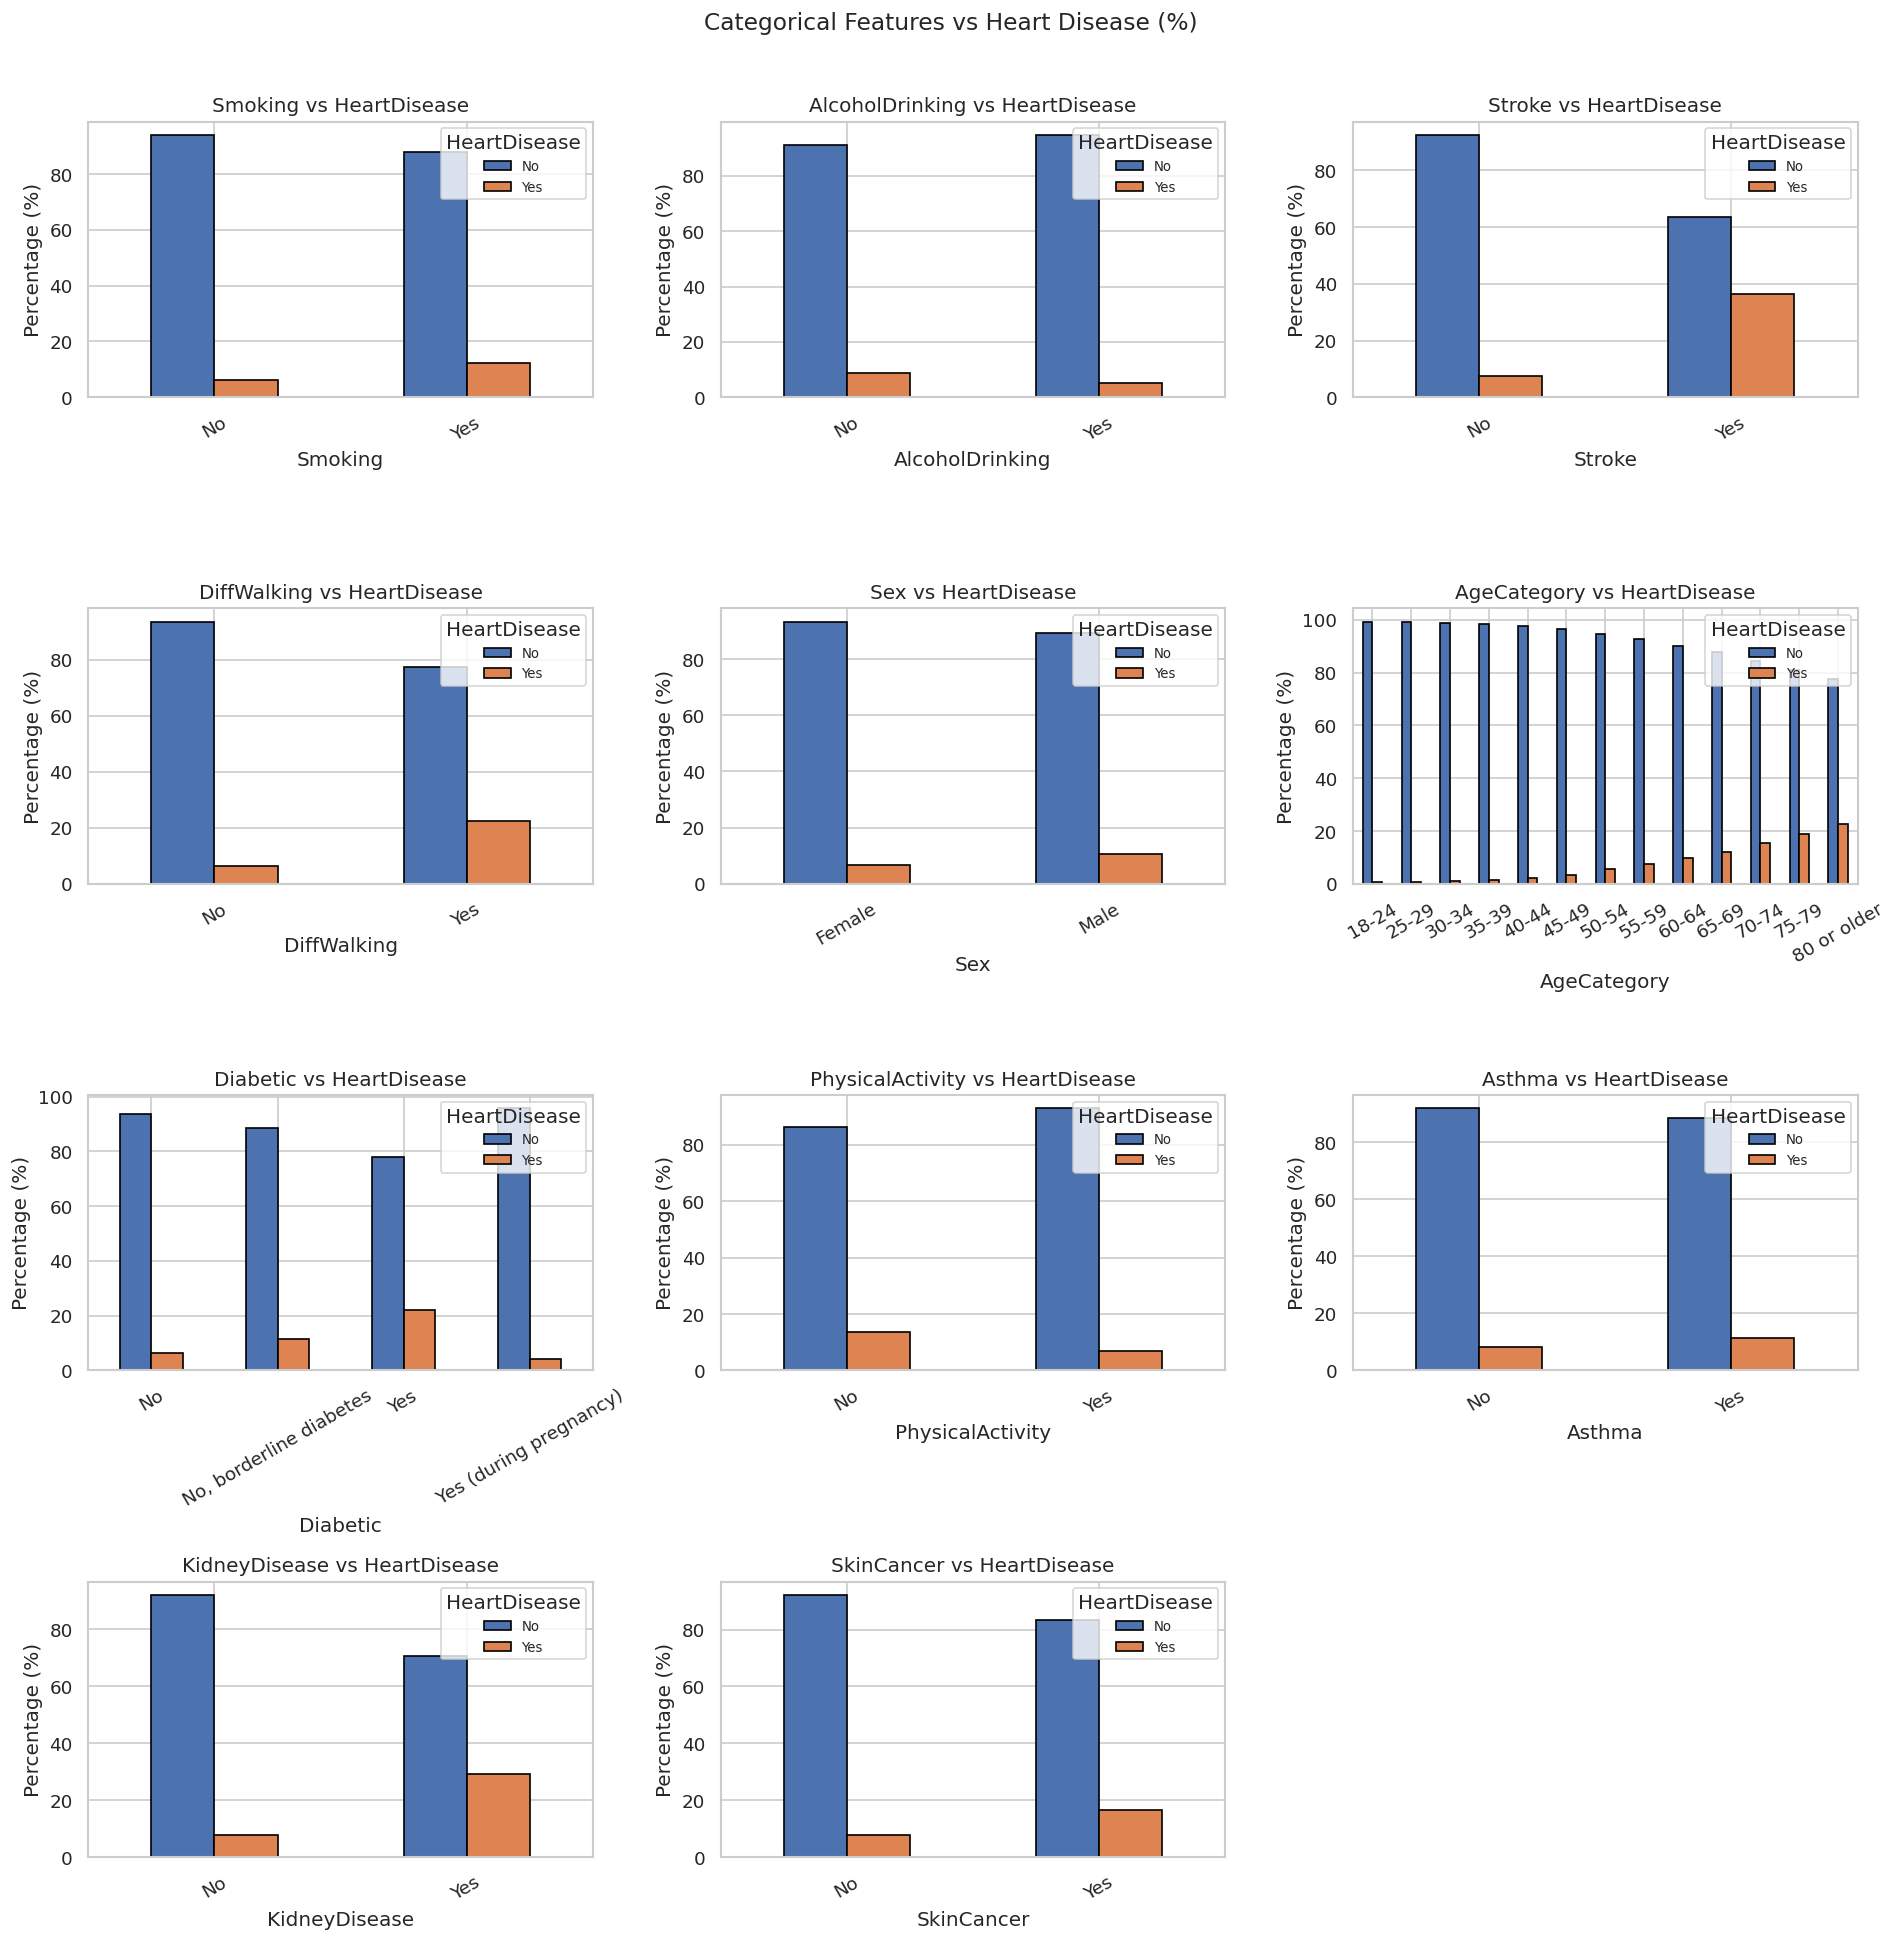

In [12]:
# ── Categorical feature distribution vs. HeartDisease ─────────────────────────
cat_cols = ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
            'Sex', 'AgeCategory', 'Diabetic', 'PhysicalActivity',
            'Asthma', 'KidneyDisease', 'SkinCancer']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['HeartDisease'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'],
            edgecolor='black', rot=30)
    axes[i].set_title(f'{col} vs HeartDisease')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='HeartDisease', loc='upper right', fontsize=8)

axes[-1].set_visible(False)   # Hide the unused 12th subplot
plt.suptitle('Categorical Features vs Heart Disease (%)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('categorical_eda.png', bbox_inches='tight')
plt.show()

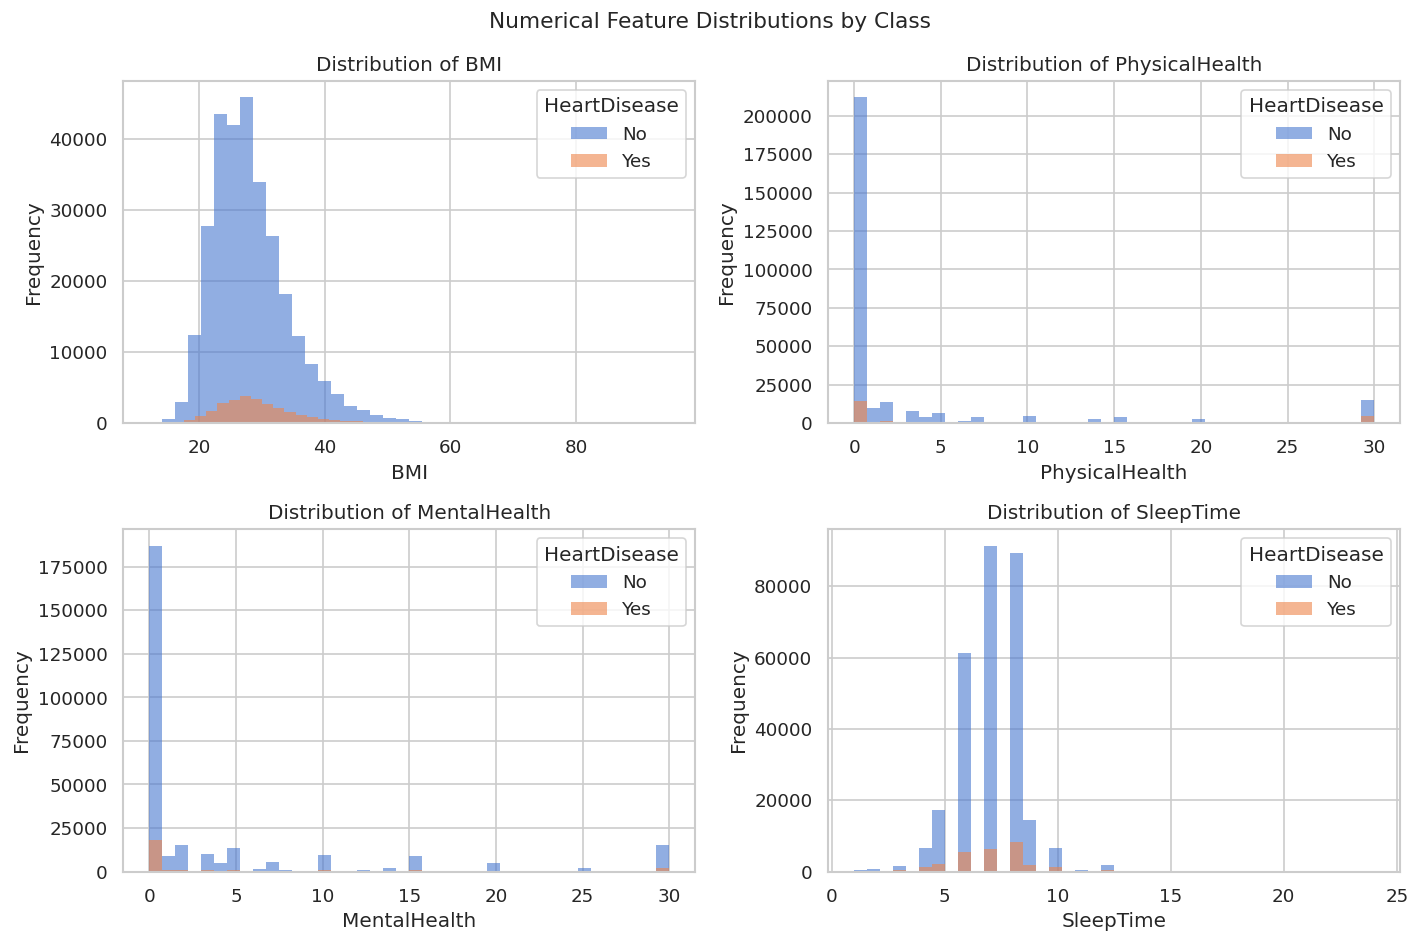

In [13]:
# ── Numerical feature distributions ──────────────────────────────────────────
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, grp in df.groupby('HeartDisease'):
        axes[i].hist(grp[col], bins=40, alpha=0.6, label=label, edgecolor='none')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(title='HeartDisease')

plt.suptitle('Numerical Feature Distributions by Class', fontsize=13)
plt.tight_layout()
plt.savefig('numerical_eda.png', bbox_inches='tight')
plt.show()

### BMI Distribution

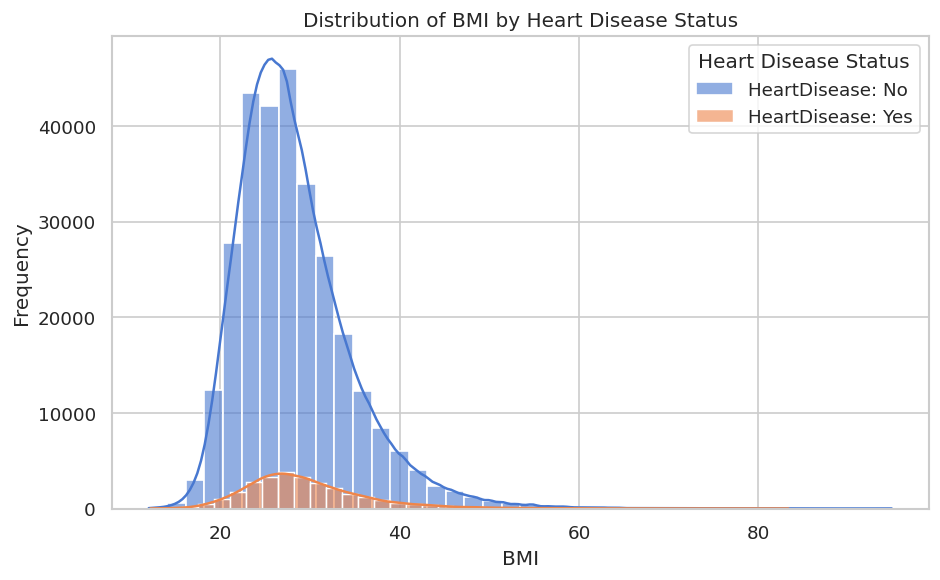

In [14]:
# Dedicated plot for BMI distribution
plt.figure(figsize=(8, 5))
for label, grp in df.groupby('HeartDisease'):
    sns.histplot(grp['BMI'], bins=40, kde=True, alpha=0.6, label=f'HeartDisease: {label}')

plt.title('Distribution of BMI by Heart Disease Status')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend(title='Heart Disease Status')
plt.tight_layout()
plt.savefig('bmi_distribution.png', bbox_inches='tight')
plt.show()

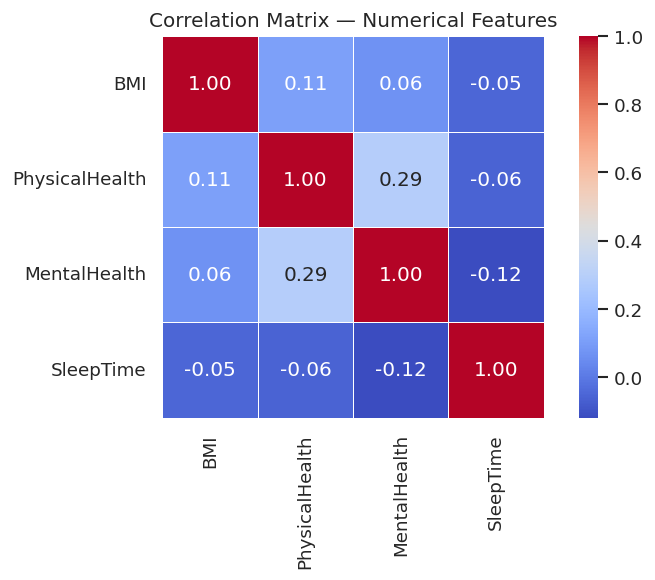

In [15]:
# ── Correlation heatmap (numerical columns only) ──────────────────────────────
num_df = df[num_cols]
plt.figure(figsize=(7, 5))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 3. Data Preprocessing

### 3.1 Handle Missing Values

In [16]:
# The Kaggle-cleaned version has no missing values, but we run this check
# defensively to make the pipeline robust to other splits of the raw survey.
print(f'Total missing cells: {df.isnull().sum().sum()}')

# If missing values are found in future data:
# - Numerical columns: fill with median (robust to outliers)
# - Categorical columns: fill with mode (most frequent category)
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after imputation:', df.isnull().sum().sum())

Total missing cells: 0
Missing values after imputation: 0


### 3.2 Encode Categorical Variables (One-Hot Encoding)

> **Why OHE?** Tree-based models can handle ordinal labels, but distance-based models (SVM, KNN) assume numeric relationships between labels. OHE avoids imposing an artificial ordinal order on nominal categories (e.g., `GenHealth: Excellent=0, Poor=4` would imply *Poor* is numerically distant from *Excellent*, which distorts Euclidean distance computations).

In [17]:
# Encode the binary target variable (Yes → 1, No → 0)
df['HeartDisease'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})

# Identify categorical columns to one-hot encode
# Exclude the target variable from OHE if it's still in `object` type at this point
cat_to_encode = df.select_dtypes(include='object').columns.tolist()
print('Columns to OHE:', cat_to_encode)

# Apply pandas get_dummies (drop_first=True removes the reference category
# to avoid multicollinearity — the 'dummy variable trap')
df_encoded = pd.get_dummies(df, columns=cat_to_encode, drop_first=True)

print(f'\nShape after encoding: {df_encoded.shape}')
print(f'Features: {df_encoded.shape[1] - 1}  |  Target: HeartDisease')

Columns to OHE: ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']

Shape after encoding: (319795, 38)
Features: 37  |  Target: HeartDisease


### 3.3 Train / Test Split (80 % / 20 %)

In [18]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# stratify=y ensures the class imbalance ratio is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Train positive rate: {y_train.mean()*100:.2f}%')
print(f'Test  positive rate: {y_test.mean()*100:.2f}%')

Training set : 255,836 samples
Test set     : 63,959 samples
Train positive rate: 8.56%
Test  positive rate: 8.56%


### 3.4 Feature Scaling (StandardScaler — SVM & KNN only)

> **Why scale for SVM and KNN but NOT for Naive Bayes?**  
> - **SVM** optimises a margin defined by Euclidean distances. Features with larger numerical ranges will dominate the kernel's distance metric, biasing the decision boundary. StandardScaler brings all features to zero mean and unit variance, ensuring every dimension contributes equally.  
> - **KNN** classifies by majority vote among the *k* nearest neighbours, measured via Euclidean distance. Without scaling, a feature like `BMI` (range 10–95) would completely overshadow a binary OHE flag (0 or 1).  
> - **Gaussian Naive Bayes** estimates per-class Gaussian distributions (mean and variance) for each feature *independently*. Because it makes no distance calculations and the parameters adapt to the natural scale of each feature, scaling provides no benefit and may distort the estimated distributions.

In [19]:
# Fit scaler ONLY on training data to prevent data leakage.
# The same fitted scaler is then applied to the test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)    # Use transform, NOT fit_transform!

print('Scaling complete.')
print(f'Mean of first feature (train, scaled): {X_train_scaled[:, 0].mean():.4f}')   # ≈ 0
print(f'Std  of first feature (train, scaled): {X_train_scaled[:, 0].std():.4f}')    # ≈ 1

Scaling complete.
Mean of first feature (train, scaled): 0.0000
Std  of first feature (train, scaled): 1.0000


---
## 4. Model Training & Hyperparameter Tuning

### 4.1 Helper: Evaluation Function

In [20]:
results = []   # Will hold one dict per model configuration

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name, hyperparams):
    """Train, predict, compute metrics, and store results."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    results.append({
        'Model': model_name,
        'Hyperparameters': hyperparams,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-score':  round(f1,   4),
        'CM':        cm,
        'y_pred':    y_pred,
    })

    print(f'\n--- {model_name} | {hyperparams} ---')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-score : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

    return y_pred

### 4.2 Support Vector Machine (SVM)

We test two kernels (Linear and RBF) and three values of the regularisation parameter **C** (0.1, 1, 10).  
- **C** controls the bias–variance trade-off: small C → wider margin, more misclassifications tolerated (high bias); large C → narrow margin, fewer training errors (high variance).

> ⚠️ **Note on runtime:** SVM on ~250 k samples is slow. The cell below subsamples 30,000 rows for a practical classroom experiment while still producing representative metrics. Remove the subsampling line for full training on a server-grade machine.

In [21]:
# ── Optional subsampling for SVM speed ──────────────────────────────────────
SUBSAMPLE = 30_000
np.random.seed(42)
idx = np.random.choice(len(X_train_scaled), SUBSAMPLE, replace=False)
X_svm_tr = X_train_scaled[idx]
y_svm_tr = y_train.values[idx]

# Full test set is always used for evaluation
svm_configs = [
    ('SVM', 'Linear, C=0.1',  SVC(kernel='linear', C=0.1,  random_state=42, class_weight='balanced')),
    ('SVM', 'Linear, C=1',    SVC(kernel='linear', C=1,    random_state=42, class_weight='balanced')),
    ('SVM', 'Linear, C=10',   SVC(kernel='linear', C=10,   random_state=42, class_weight='balanced')),
    ('SVM', 'RBF, C=0.1',     SVC(kernel='rbf',    C=0.1,  random_state=42, class_weight='balanced')),
    ('SVM', 'RBF, C=1',       SVC(kernel='rbf',    C=1,    random_state=42, class_weight='balanced')),
    ('SVM', 'RBF, C=10',      SVC(kernel='rbf',    C=10,   random_state=42, class_weight='balanced')),
]

print('Training SVM variants... (this may take a few minutes)')
for name, params, model in svm_configs:
    evaluate_model(model, X_svm_tr, X_test_scaled, y_svm_tr,
                   y_test, name, params)

Training SVM variants... (this may take a few minutes)

--- SVM | Linear, C=0.1 ---
  Accuracy : 0.7419
  Precision: 0.2189
  Recall   : 0.7845
  F1-score : 0.3423

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.97      0.74      0.84     58484
   Heart Disease       0.22      0.78      0.34      5475

        accuracy                           0.74     63959
       macro avg       0.60      0.76      0.59     63959
    weighted avg       0.91      0.74      0.80     63959


--- SVM | Linear, C=1 ---
  Accuracy : 0.7416
  Precision: 0.2187
  Recall   : 0.7850
  F1-score : 0.3421

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.97      0.74      0.84     58484
   Heart Disease       0.22      0.79      0.34      5475

        accuracy                           0.74     63959
       macro avg       0.60      0.76      0.59     63959
    weighted avg       0.91      0.74 

### 4.3 K-Nearest Neighbours (KNN)

| K value | Effect |
|---------|--------|
| Small K (e.g. 3) | Low bias, high variance — sensitive to noise and outliers |
| Medium K (e.g. 11) | Better bias–variance trade-off |
| Large K | High bias, low variance — decision boundary becomes smoother but may miss local patterns |

In [22]:
knn_configs = [
    ('KNN', 'K=3',  KNeighborsClassifier(n_neighbors=3)),
    ('KNN', 'K=5',  KNeighborsClassifier(n_neighbors=5)),
    ('KNN', 'K=11', KNeighborsClassifier(n_neighbors=11)),
]

print('Training KNN variants...')
for name, params, model in knn_configs:
    evaluate_model(model, X_train_scaled, X_test_scaled,
                   y_train, y_test, name, params)

Training KNN variants...

--- KNN | K=3 ---
  Accuracy : 0.8971
  Precision: 0.3161
  Recall   : 0.1741
  F1-score : 0.2245

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.96      0.94     58484
   Heart Disease       0.32      0.17      0.22      5475

        accuracy                           0.90     63959
       macro avg       0.62      0.57      0.58     63959
    weighted avg       0.87      0.90      0.88     63959


--- KNN | K=5 ---
  Accuracy : 0.9055
  Precision: 0.3637
  Recall   : 0.1392
  F1-score : 0.2013

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.92      0.98      0.95     58484
   Heart Disease       0.36      0.14      0.20      5475

        accuracy                           0.91     63959
       macro avg       0.64      0.56      0.58     63959
    weighted avg       0.88      0.91      0.89     63959


--- KNN | K=11 ---
  Accur

### 4.4 Gaussian Naive Bayes

GNB makes the strong conditional independence assumption. It uses the raw (unscaled) encoded features because it estimates feature distributions per-class individually.

In [23]:
# Use UNSCALED data for GNB
gnb_model = GaussianNB()
evaluate_model(gnb_model, X_train, X_test,
               y_train, y_test, 'Gaussian NB', 'Default (var_smoothing=1e-9)')


--- Gaussian NB | Default (var_smoothing=1e-9) ---
  Accuracy : 0.7309
  Precision: 0.2046
  Recall   : 0.7423
  F1-score : 0.3208

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.97      0.73      0.83     58484
   Heart Disease       0.20      0.74      0.32      5475

        accuracy                           0.73     63959
       macro avg       0.59      0.74      0.58     63959
    weighted avg       0.90      0.73      0.79     63959



array([0, 0, 0, ..., 1, 1, 1], shape=(63959,))

---
## 5. Evaluation — Consolidated Comparison Table

In [24]:
# Build comparison DataFrame (exclude CM and y_pred columns for display)
summary_cols = ['Model', 'Hyperparameters', 'Accuracy', 'Precision', 'Recall', 'F1-score']
results_df = pd.DataFrame(results)[summary_cols]

# Highlight best F1-score
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #d4edda' if v else '' for v in is_max]

styled = (results_df.style
          .apply(highlight_max, subset=['Accuracy', 'Precision', 'Recall', 'F1-score'])
          .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
                   'Recall': '{:.4f}', 'F1-score': '{:.4f}'})
          .set_caption('Model Performance Comparison (Green = Best per Metric)'))
styled

,Model,Hyperparameters,Accuracy,Precision,Recall,F1-score
0,SVM,"Linear, C=0.1",0.7419,0.2189,0.7845,0.3423
1,SVM,"Linear, C=1",0.7416,0.2187,0.7850,0.3421
2,SVM,"Linear, C=10",0.7417,0.2188,0.7848,0.3422
3,SVM,"RBF, C=0.1",0.7205,0.2075,0.8033,0.3298
4,SVM,"RBF, C=1",0.7667,0.2226,0.6921,0.3368
5,SVM,"RBF, C=10",0.8025,0.2061,0.4583,0.2843
6,KNN,K=3,0.8971,0.3161,0.1741,0.2245
7,KNN,K=5,0.9055,0.3637,0.1392,0.2013
8,KNN,K=11,0.9120,0.4381,0.1003,0.1632
9,Gaussian NB,Default (var_smoothing=1e-9),0.7309,0.2046,0.7423,0.3208


## 6. Confusion Matrix Plots

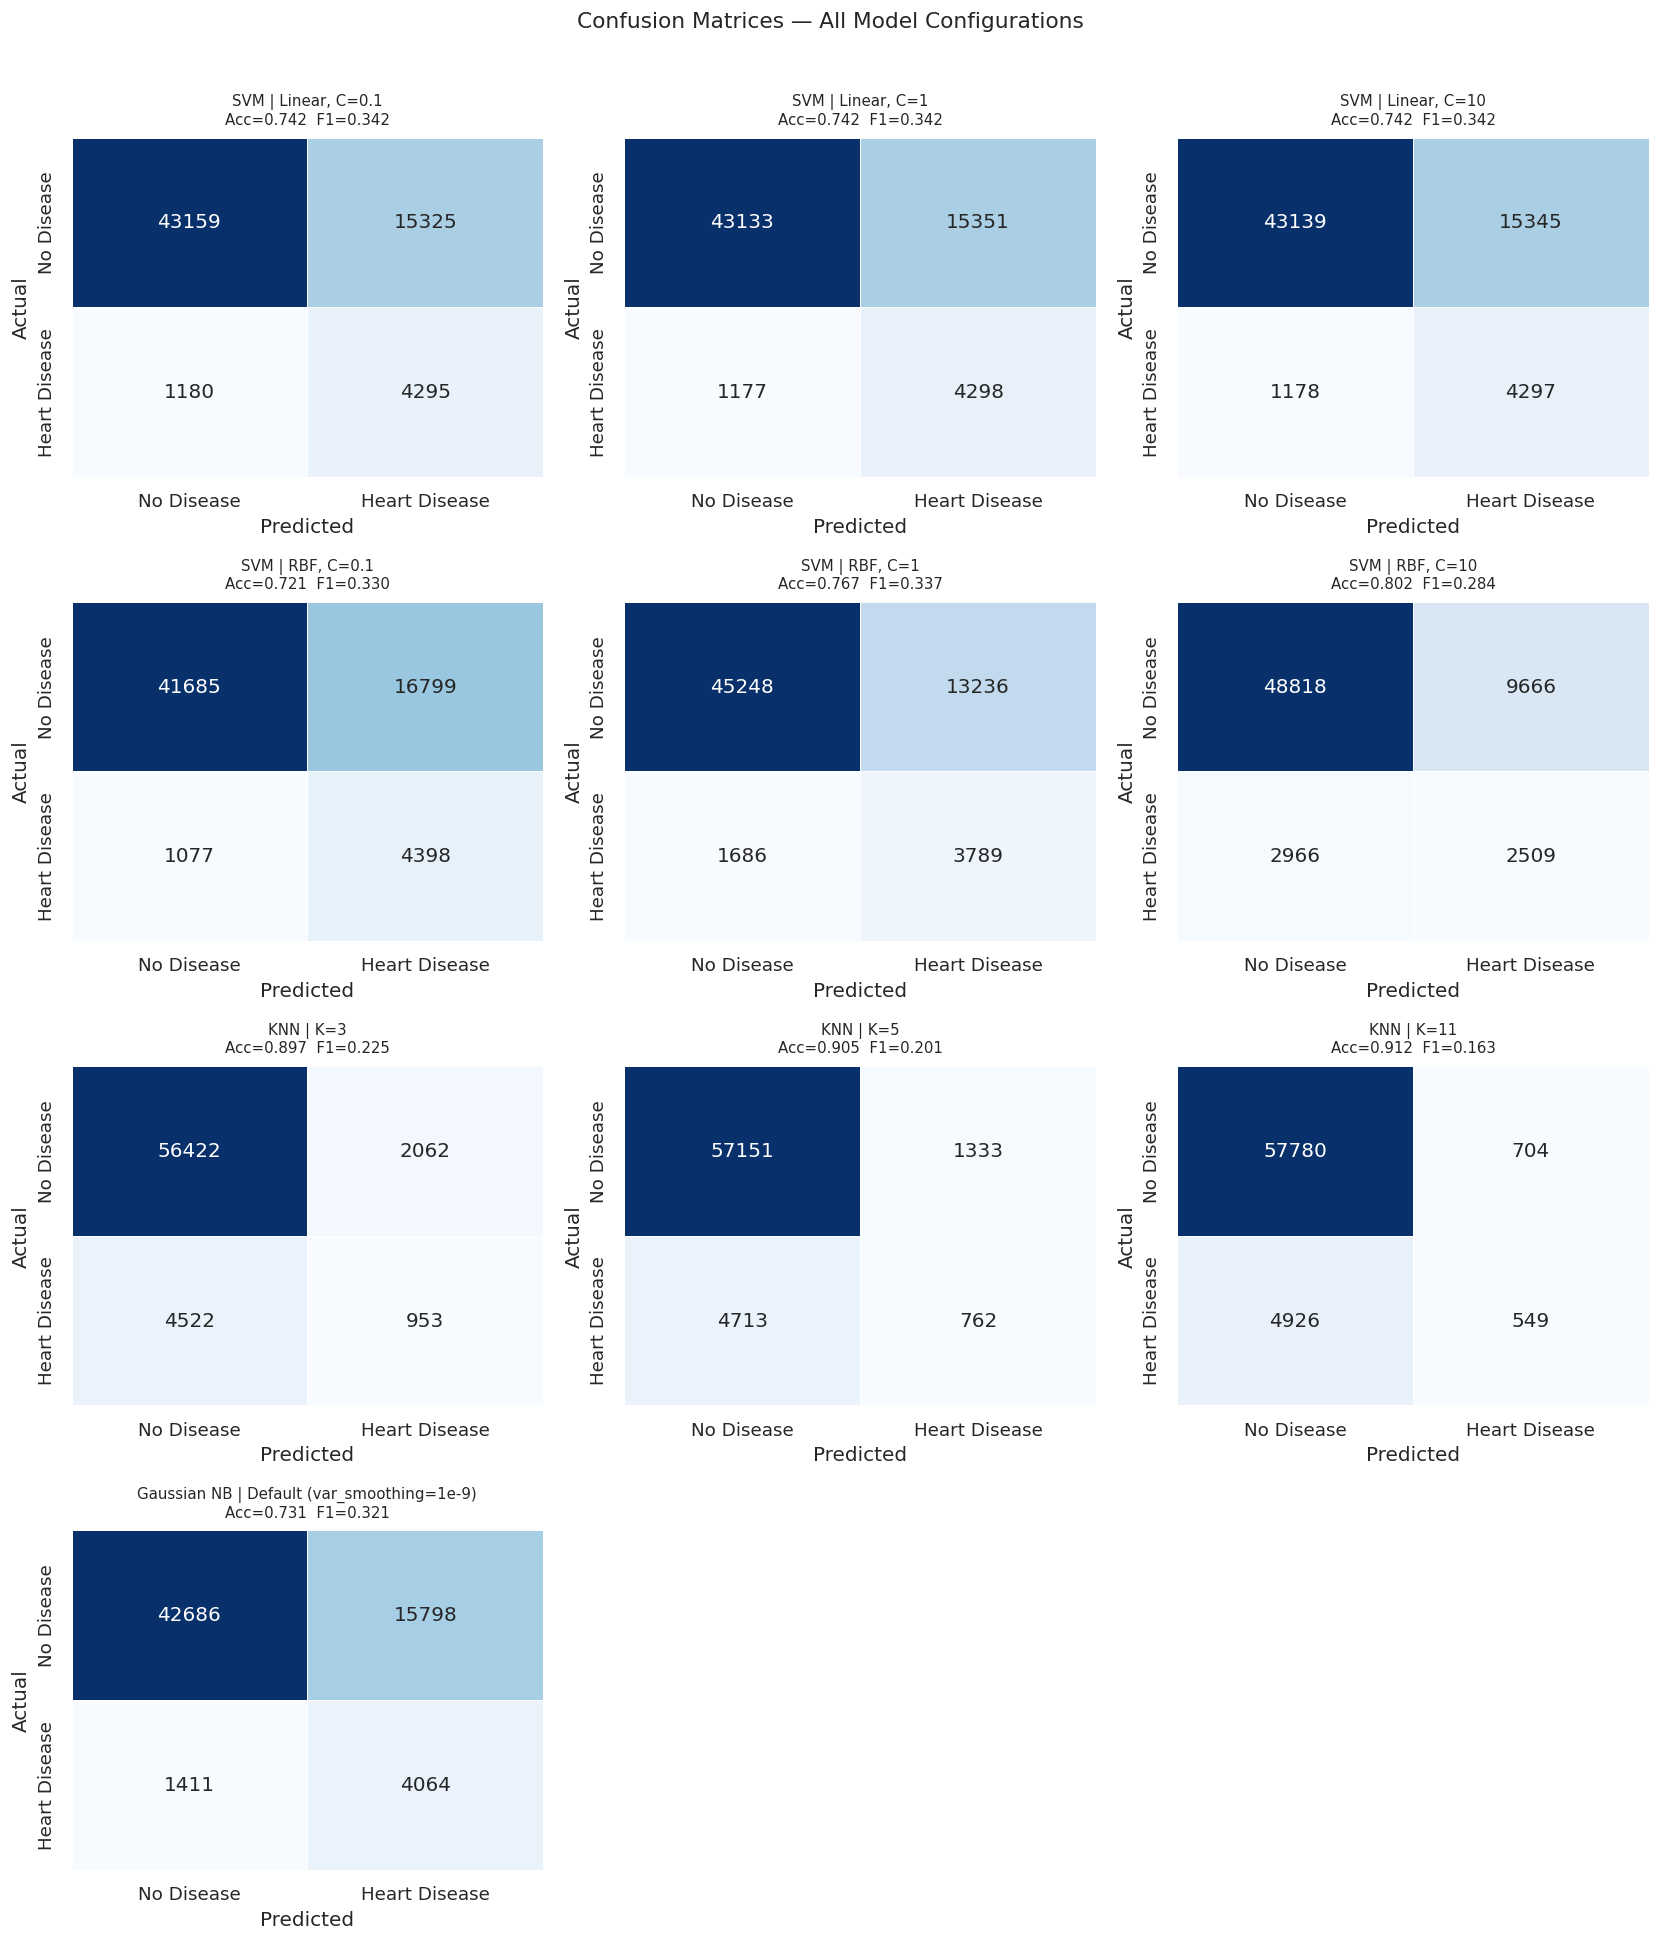

In [25]:
def plot_confusion_matrix(cm, title, ax):
    """Plot a confusion matrix as a heatmap."""
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=9, pad=8)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

n_models = len(results)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()

for i, r in enumerate(results):
    plot_confusion_matrix(
        r['CM'],
        f"{r['Model']} | {r['Hyperparameters']}\n"
        f"Acc={r['Accuracy']:.3f}  F1={r['F1-score']:.3f}",
        axes[i]
    )

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Model Configurations', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

## 7. Model Selection — Metric Bar Chart

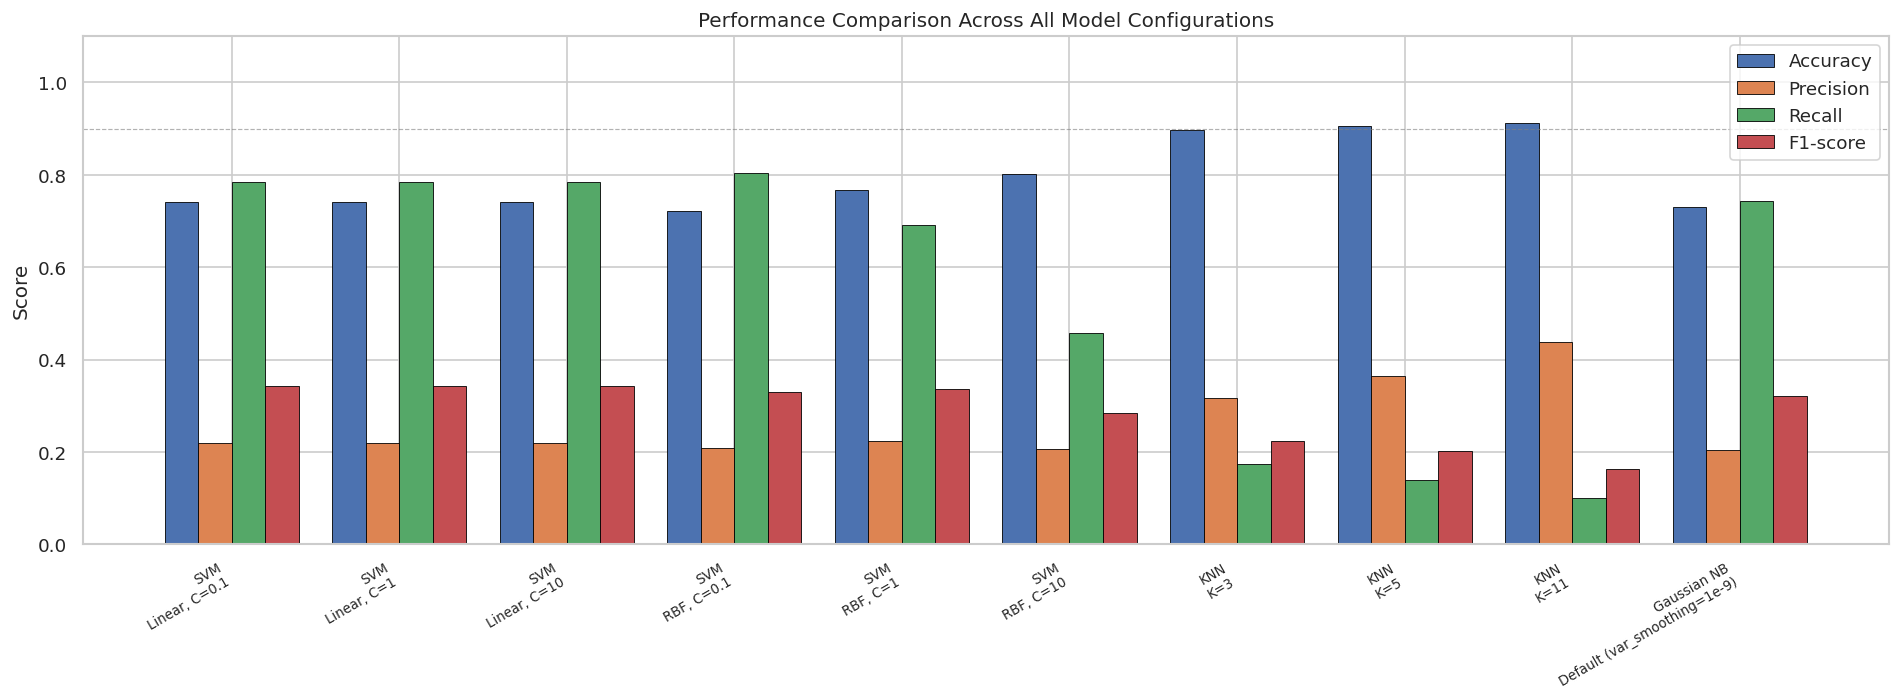

In [26]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x      = np.arange(len(results_df))
width  = 0.2
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width,
           label=metric, color=color, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(
    [f"{r['Model']}\n{r['Hyperparameters']}" for _, r in results_df.iterrows()],
    rotation=30, ha='right', fontsize=8
)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Performance Comparison Across All Model Configurations')
ax.legend(loc='upper right')
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.tight_layout()
plt.savefig('metric_comparison.png', bbox_inches='tight')
plt.show()

## 8. Bias–Variance Analysis: KNN

As K increases, the model becomes smoother (higher bias, lower variance).

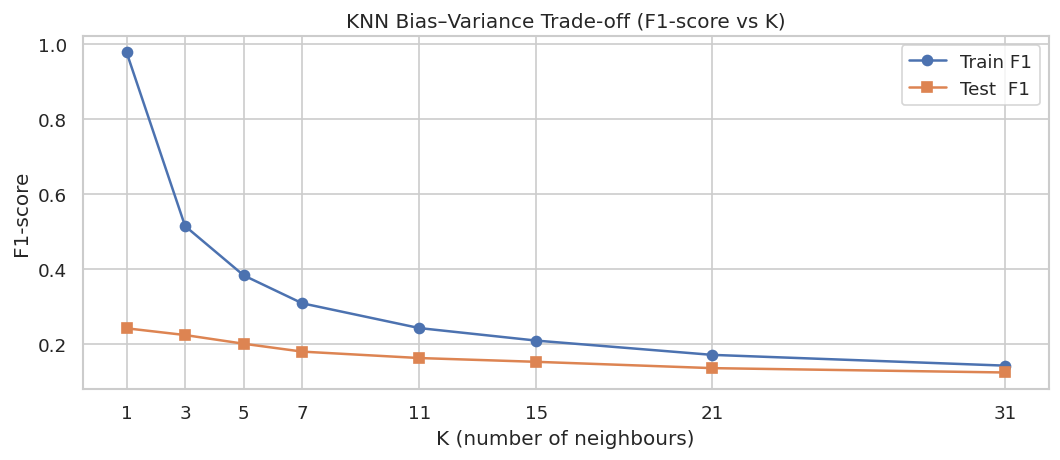

In [27]:
k_range = [1, 3, 5, 7, 11, 15, 21, 31]
train_f1s, test_f1s = [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_f1s.append(f1_score(y_train, knn.predict(X_train_scaled), zero_division=0))
    test_f1s.append( f1_score(y_test,  knn.predict(X_test_scaled),  zero_division=0))

plt.figure(figsize=(9, 4))
plt.plot(k_range, train_f1s, 'o-', label='Train F1', color='#4C72B0')
plt.plot(k_range, test_f1s,  's-', label='Test  F1', color='#DD8452')
plt.xlabel('K (number of neighbours)')
plt.ylabel('F1-score')
plt.title('KNN Bias–Variance Trade-off (F1-score vs K)')
plt.legend()
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('knn_bias_variance.png', bbox_inches='tight')
plt.show()

---
## 9. Summary & Recommendation

### Key Observations

| Observation | Explanation |
|-------------|-------------|
| High accuracy but low recall for positive class | Due to class imbalance (~9% positive) — the model can achieve ~91% accuracy by predicting *No* for every sample |
| SVM RBF generally outperforms linear SVM | The non-linear RBF kernel captures complex decision boundaries that a linear hyperplane misses |
| GNB shows high recall at cost of precision | The independence assumption causes GNB to flag many borderline cases as positive |
| KNN performance degrades for very small K | K=3 overfits to local noise; K=11 generalises better on this dataset |

### Clinical Recommendation

In a medical screening context, **false negatives** (missed heart disease cases) are clinically more dangerous than **false positives** (unnecessary follow-up tests).  
- A model with **higher recall** is preferable: it minimises the risk of sending a sick patient home untreated.  
- **GNB** tends to maximise recall and is the safest choice for first-pass screening.  
- **SVM-RBF (C=1 or C=10)** with `class_weight='balanced'` offers a better overall F1 while maintaining reasonable recall.

### Future Work
- Apply **SMOTE** (Synthetic Minority Oversampling Technique) to address class imbalance
- Evaluate **Random Forest**, **XGBoost**, and **LightGBM** ensemble methods
- Hyperparameter optimisation via **GridSearchCV** or **Optuna**
- Threshold tuning to improve recall for positive class